FINAL DBS ARTIFACT DETECTION - TARGET SUBJECTS WITH PLOTS

Analyzing 6 target subjects:
  🔴 sub-01 (RCS)
  🔵 sub-05 (PERCEPT)
  🔵 sub-07 (PERCEPT)
  🔵 sub-10 (PERCEPT)
  🔴 sub-12 (RCS)
  🔴 sub-14 (RCS)

--------------------------------------------------
📊 Processing sub-01... (RCS)
--------------------------------------------------
  Left: ✅ Freq=119.8Hz, Z=18.2σ, SNR=30.36


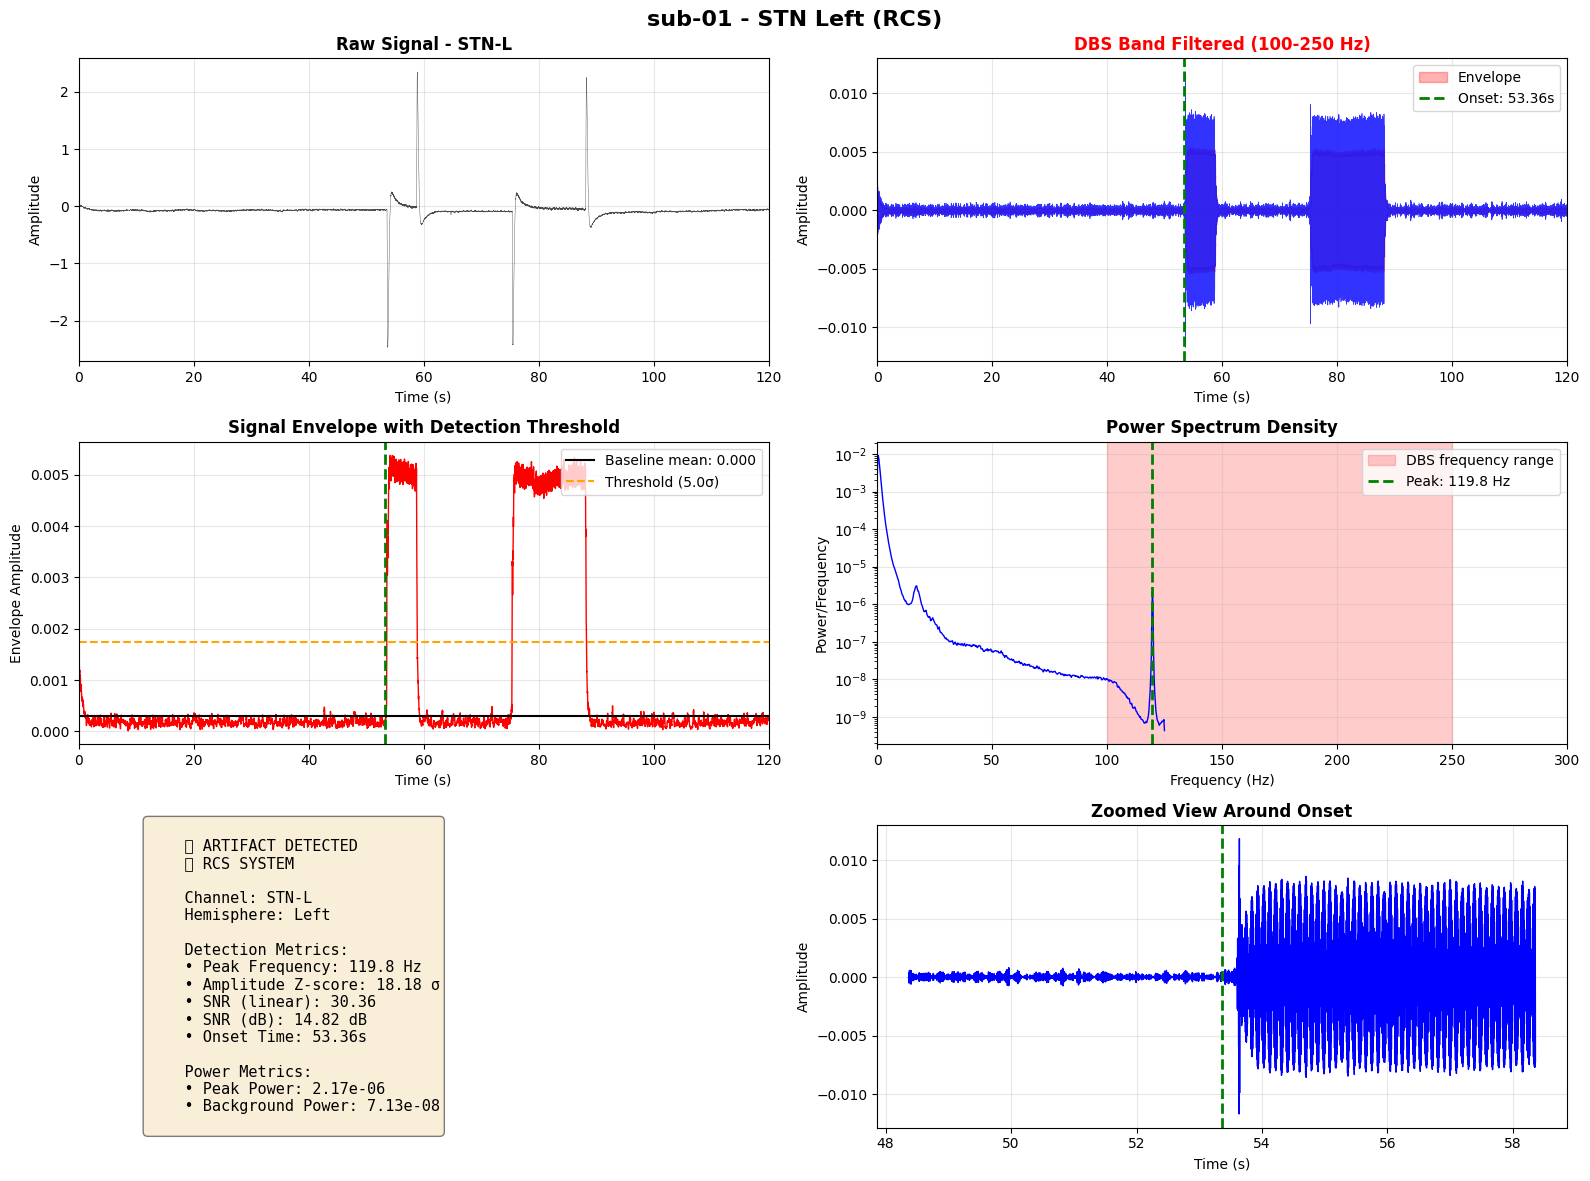

  Right: ✅ Freq=119.8Hz, Z=10736.7σ, SNR=1.35


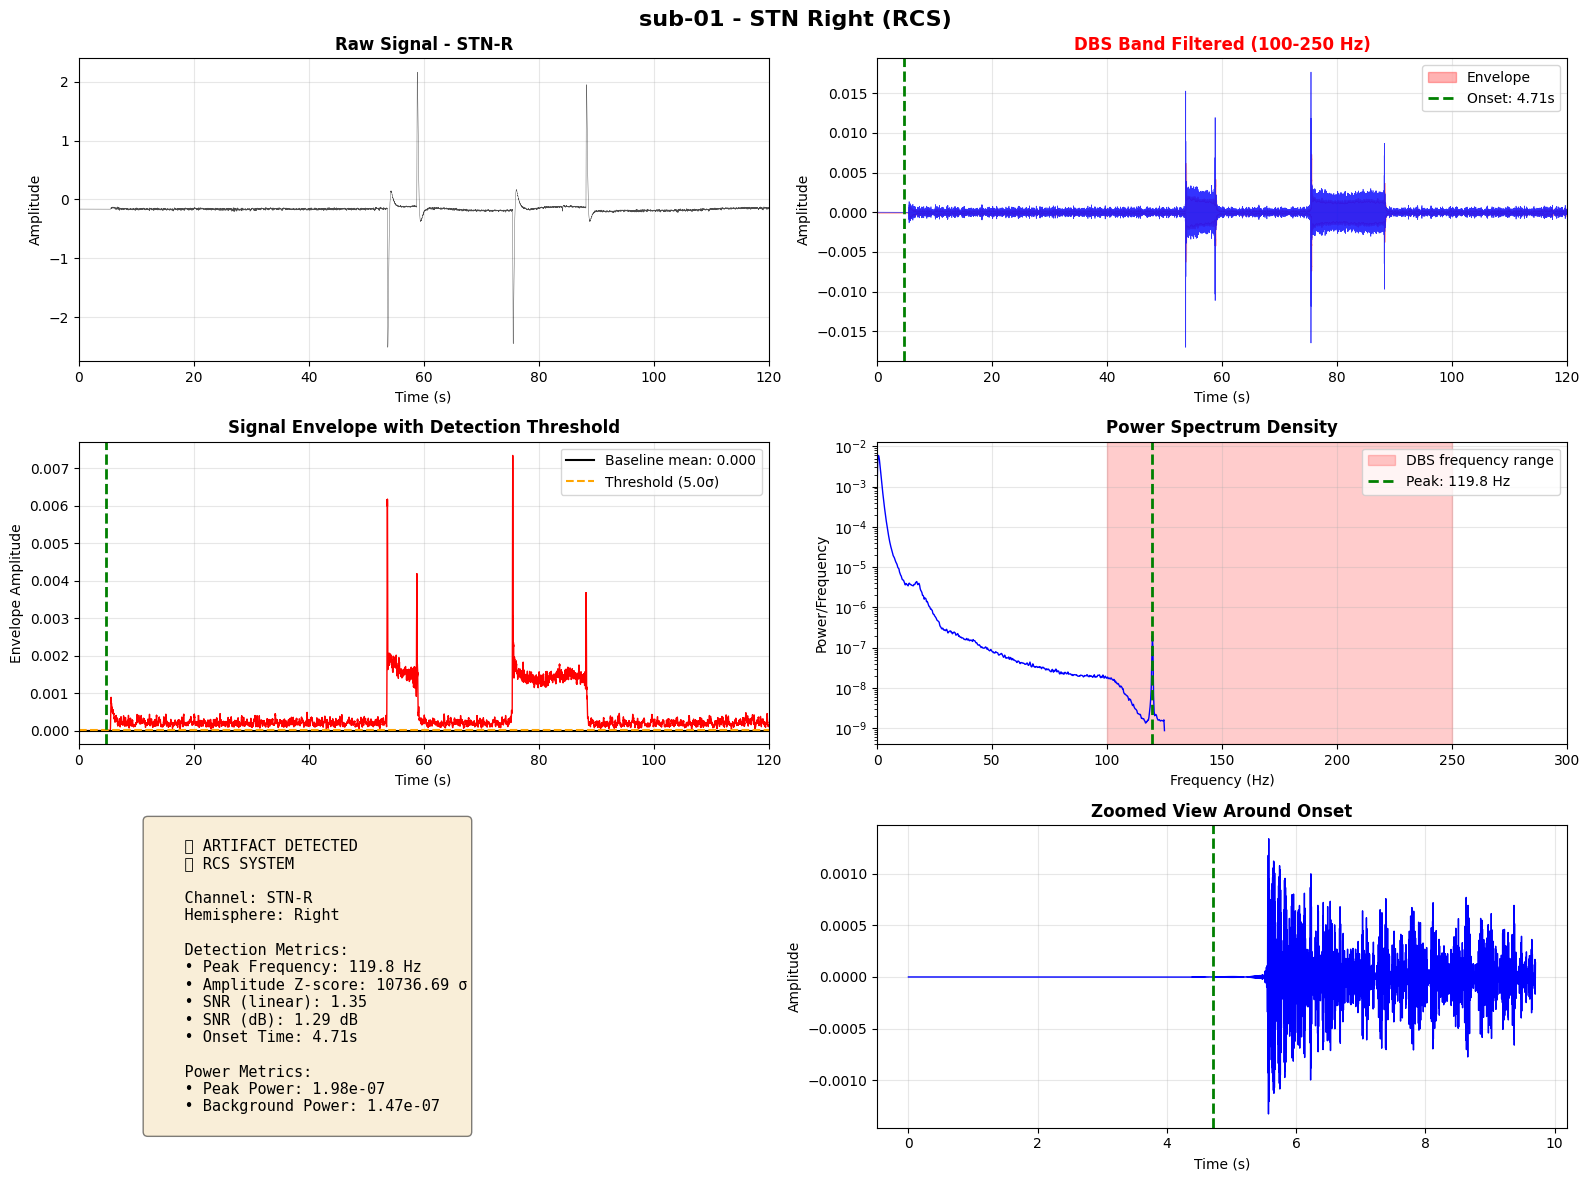


--------------------------------------------------
📊 Processing sub-05... (PERCEPT)
--------------------------------------------------
  Left: ❌ Freq=100.0Hz, Z=6.6σ, SNR=0.05


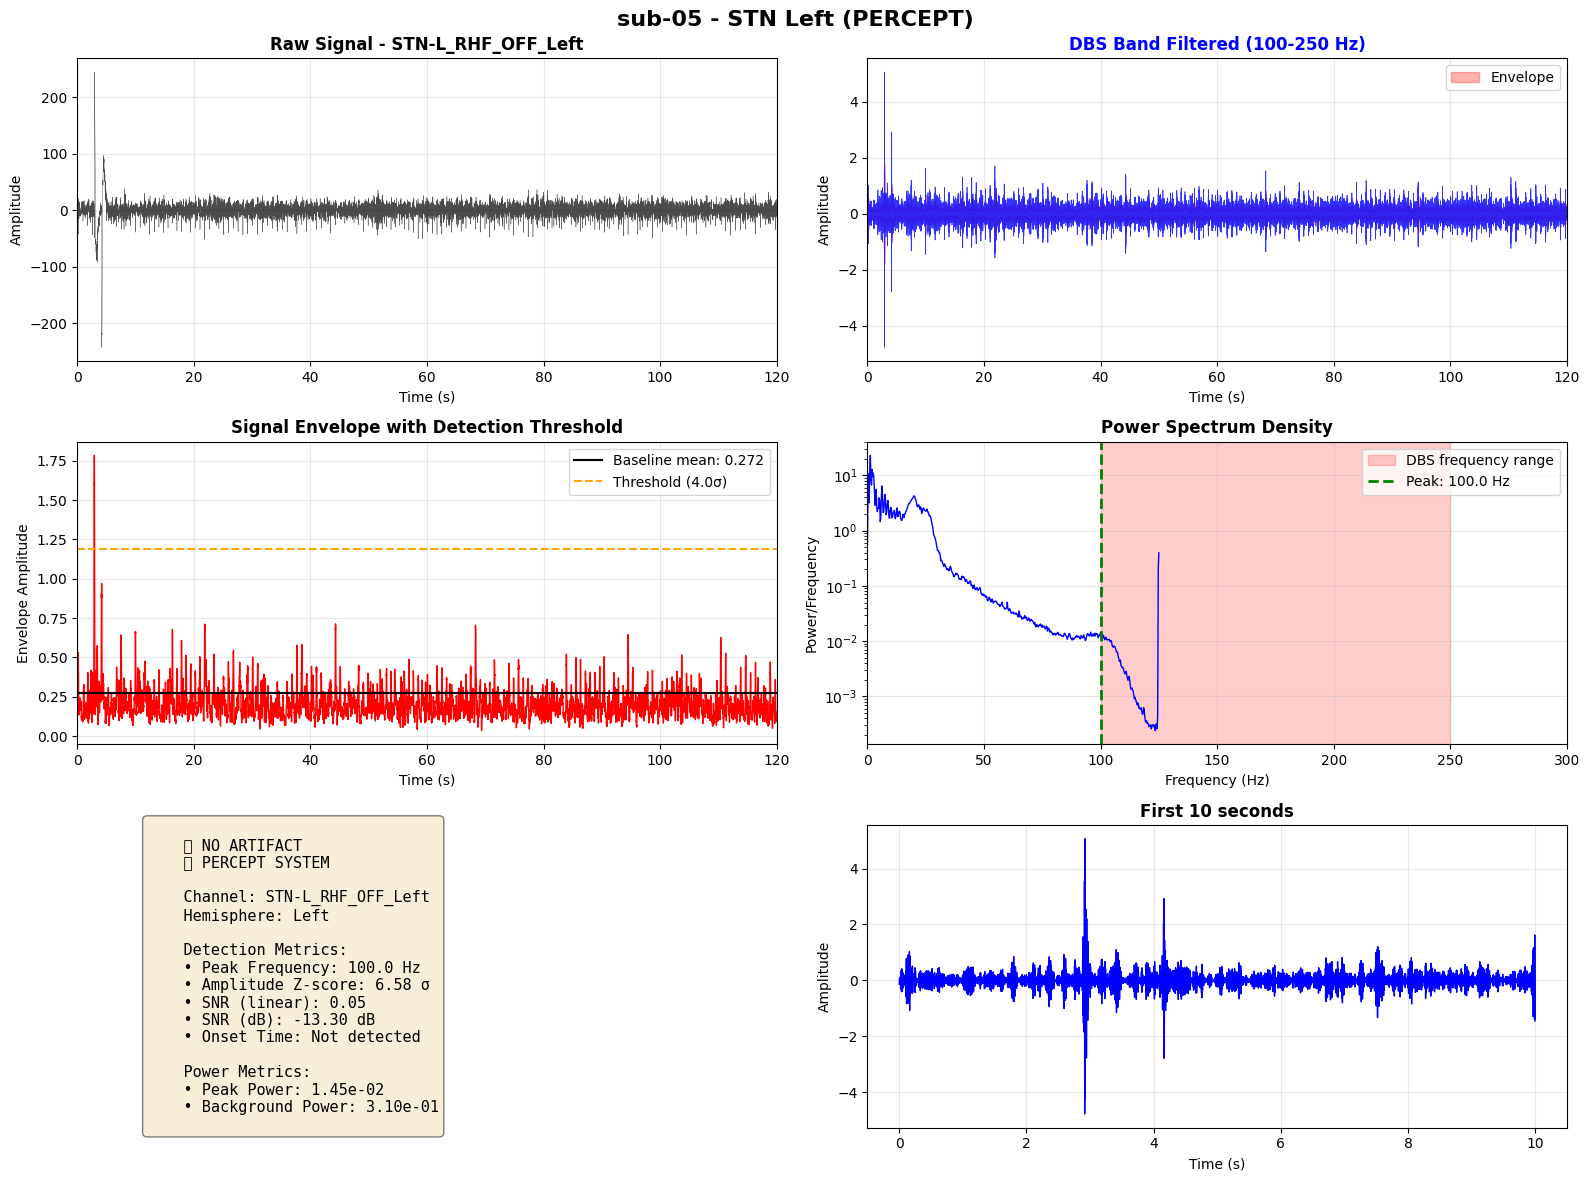

  Right: ✅ Freq=123.8Hz, Z=4.4σ, SNR=1.11


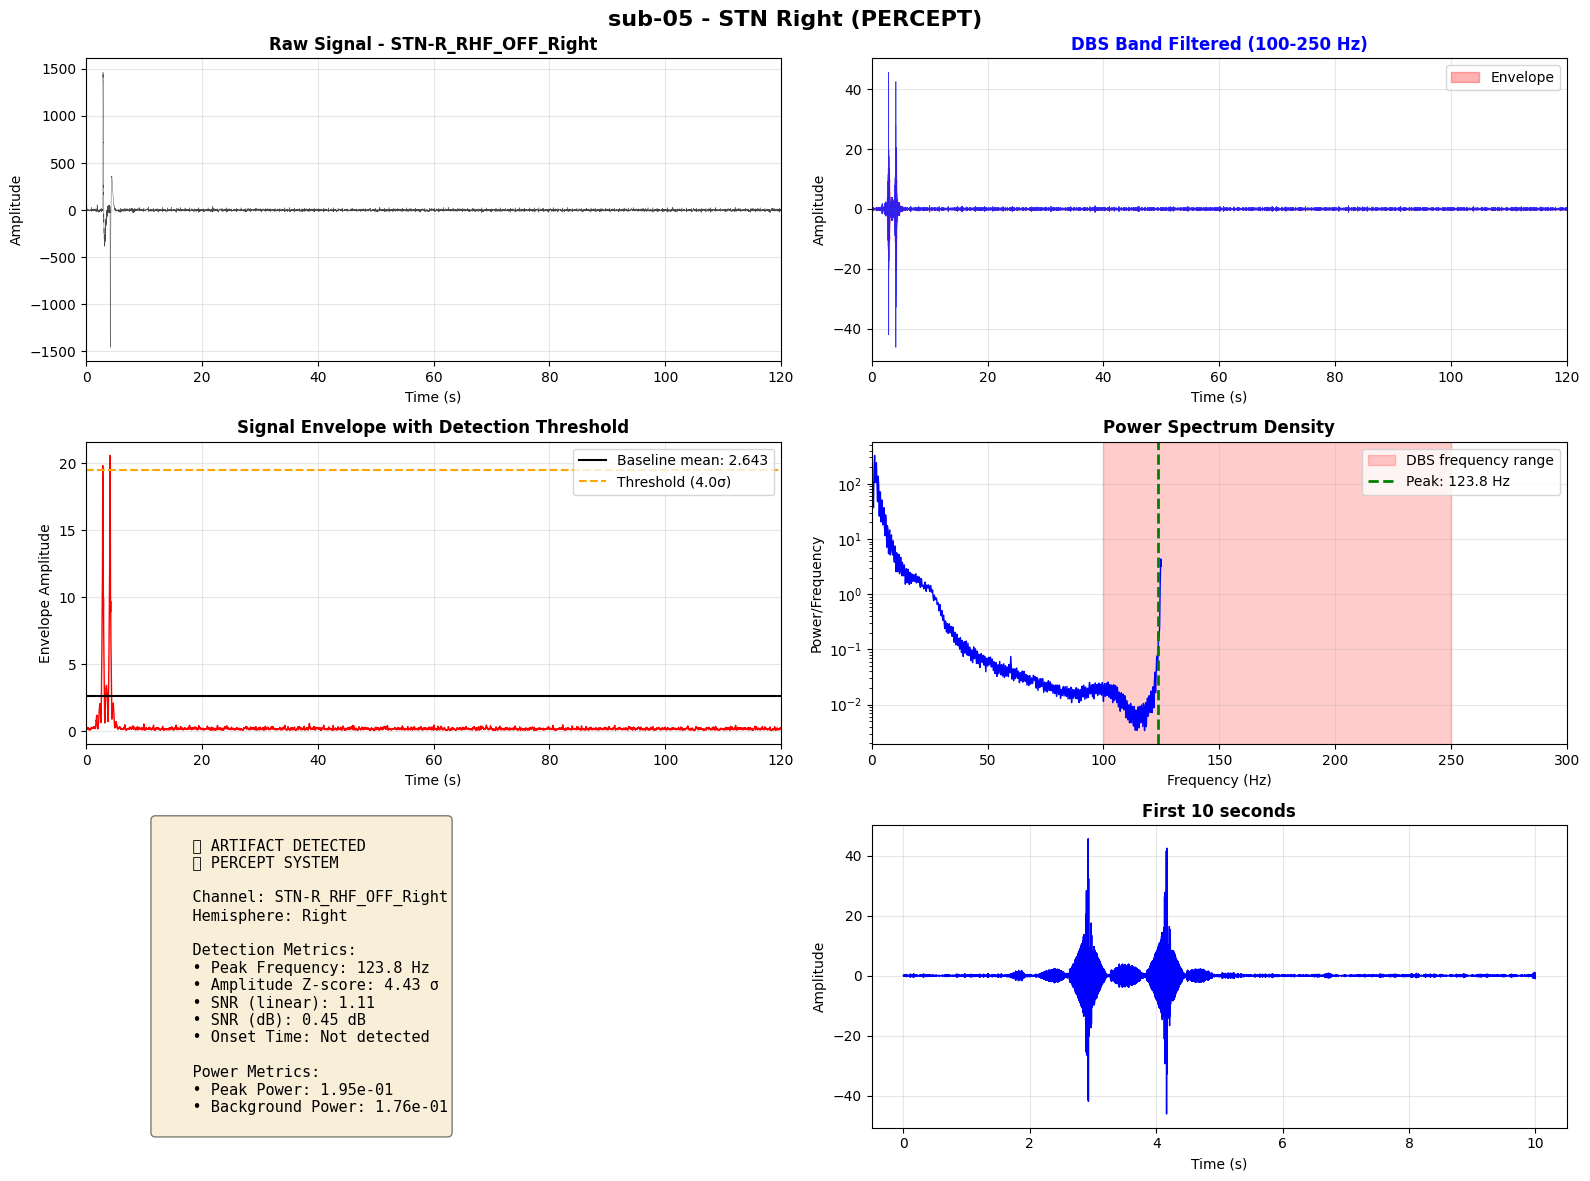


--------------------------------------------------
📊 Processing sub-07... (PERCEPT)
--------------------------------------------------
  Left: ✅ Freq=107.2Hz, Z=10.4σ, SNR=1.37


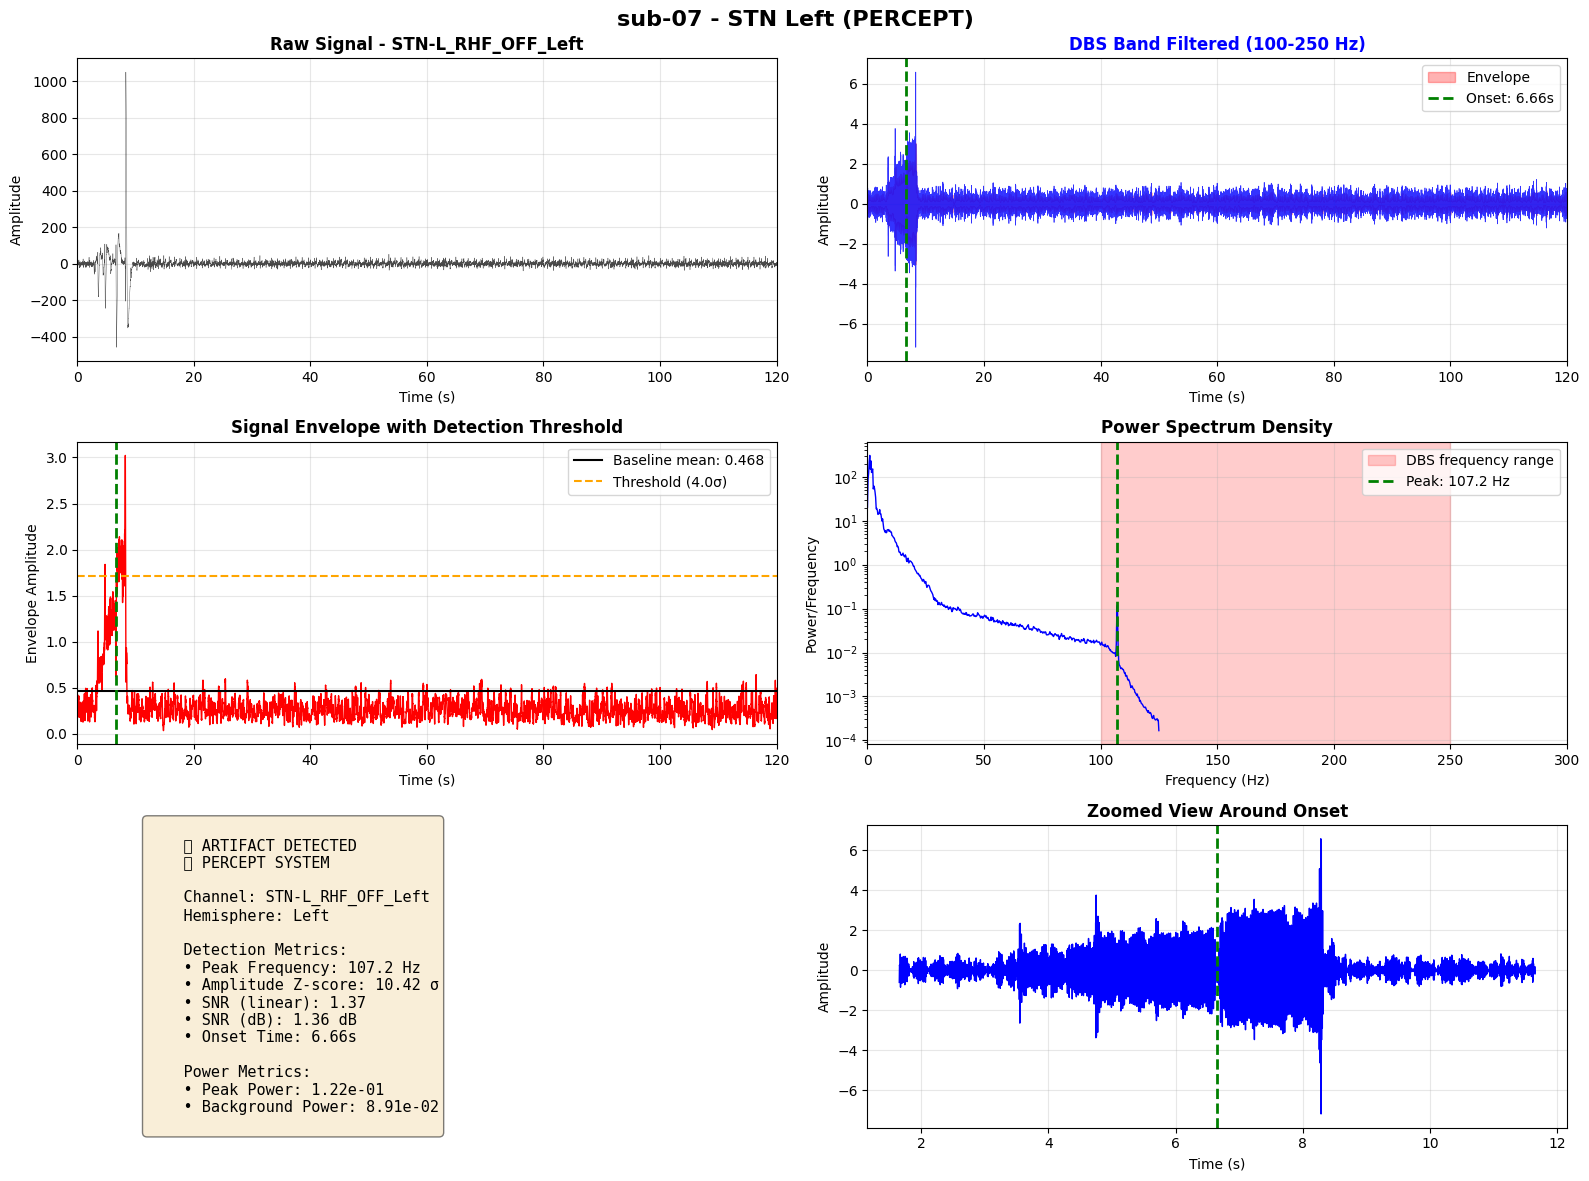


--------------------------------------------------
📊 Processing sub-10... (PERCEPT)
--------------------------------------------------
  Left: ✅ Freq=107.2Hz, Z=20.5σ, SNR=3.28


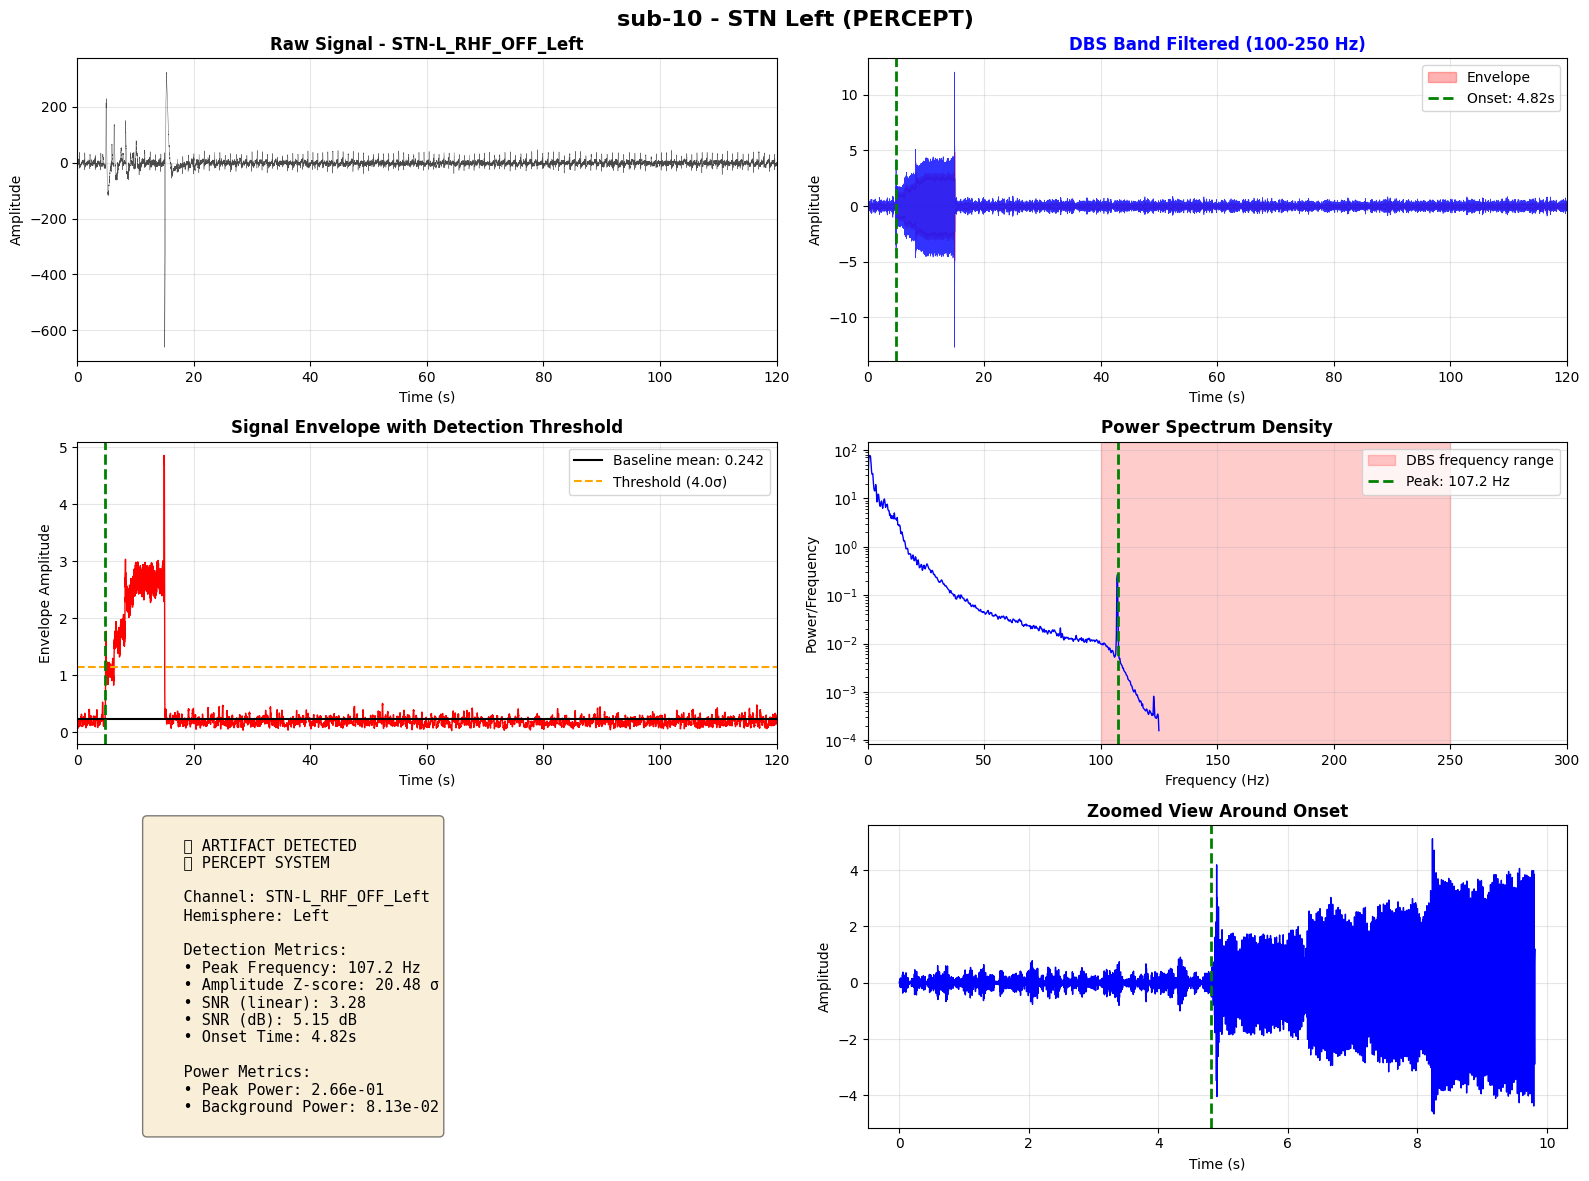

  Right: ❌ Freq=101.0Hz, Z=5.0σ, SNR=0.11


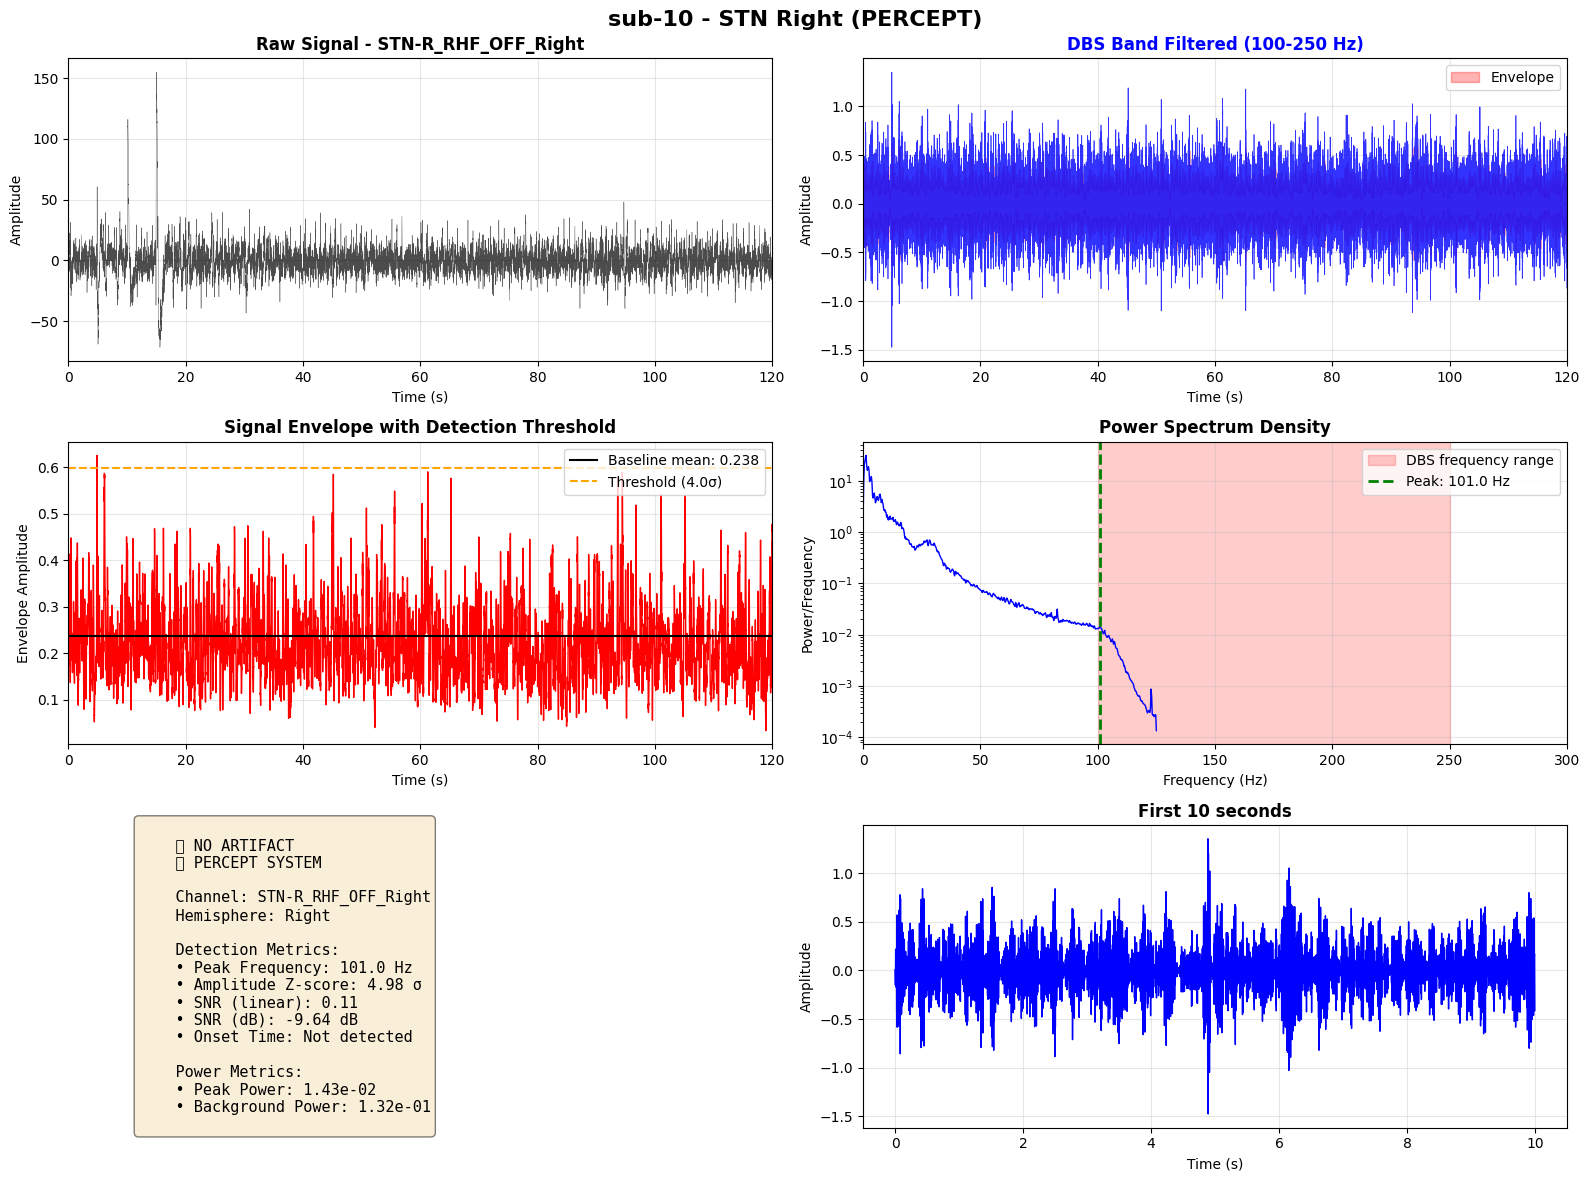


--------------------------------------------------
📊 Processing sub-12... (RCS)
--------------------------------------------------
  Left: ✅ Freq=119.8Hz, Z=34.2σ, SNR=0.30


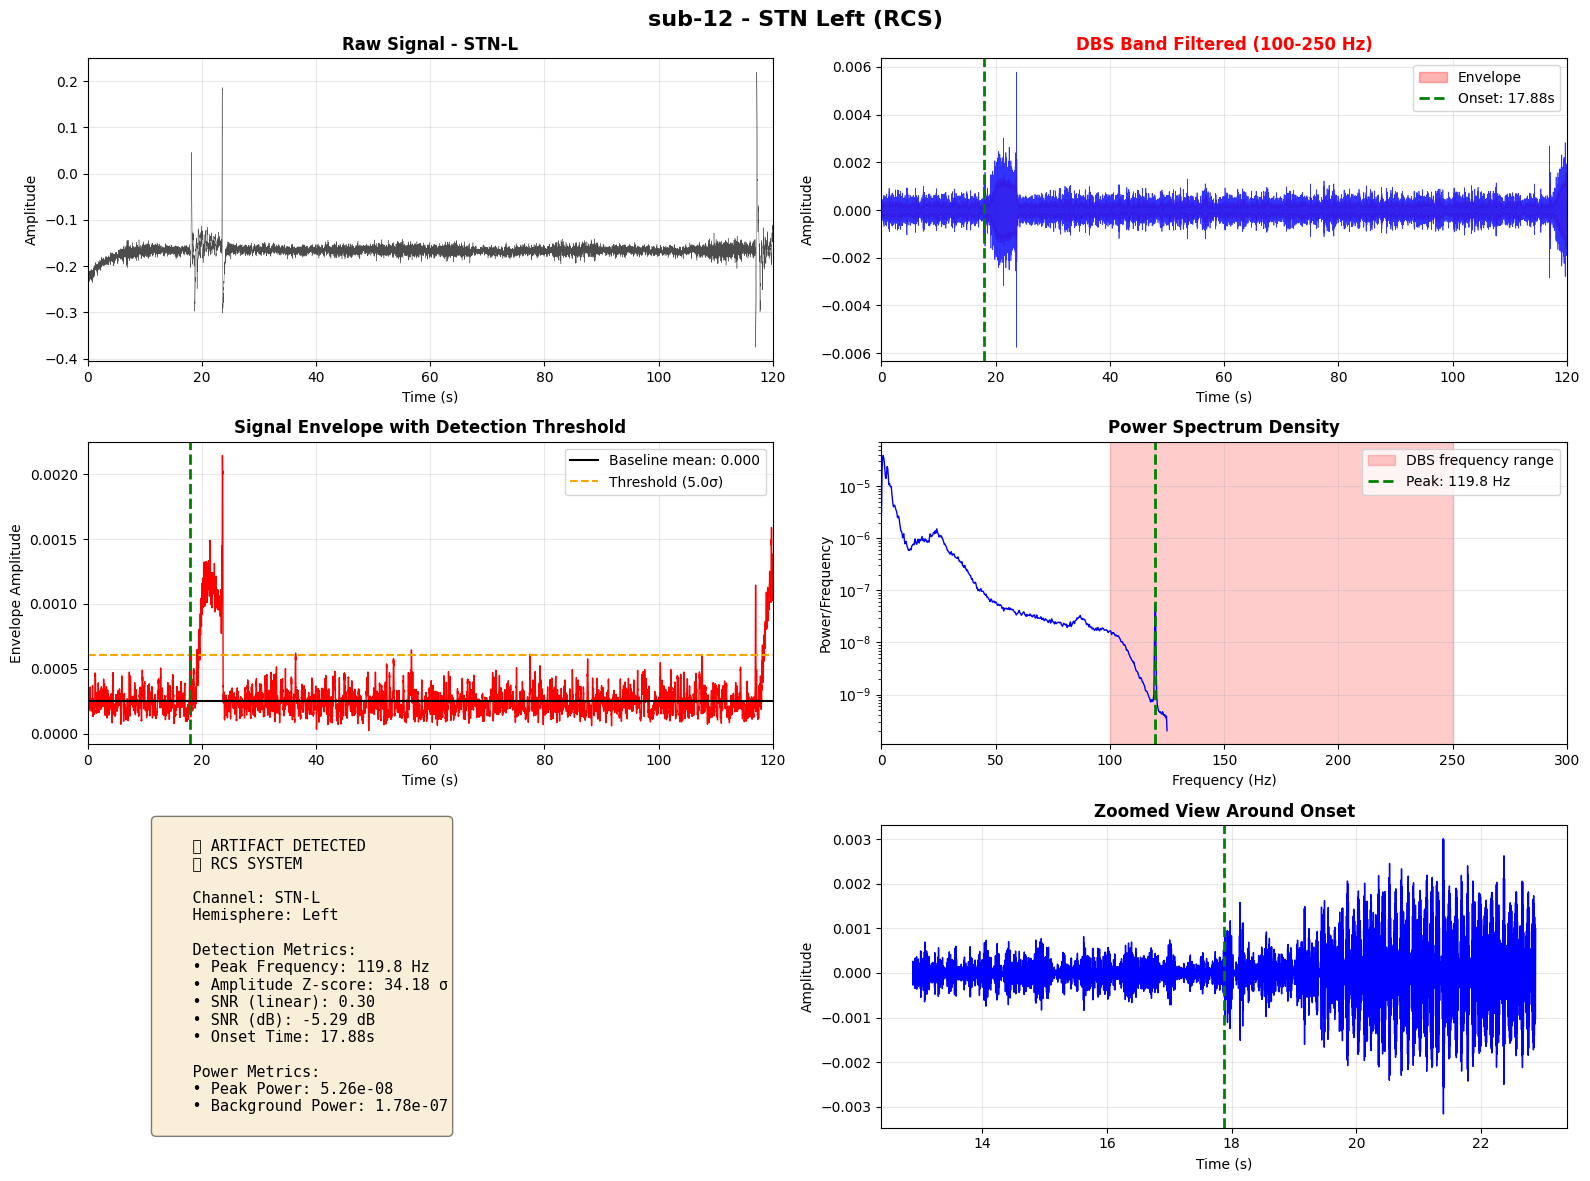

  Right: ✅ Freq=119.8Hz, Z=150.0σ, SNR=13.02


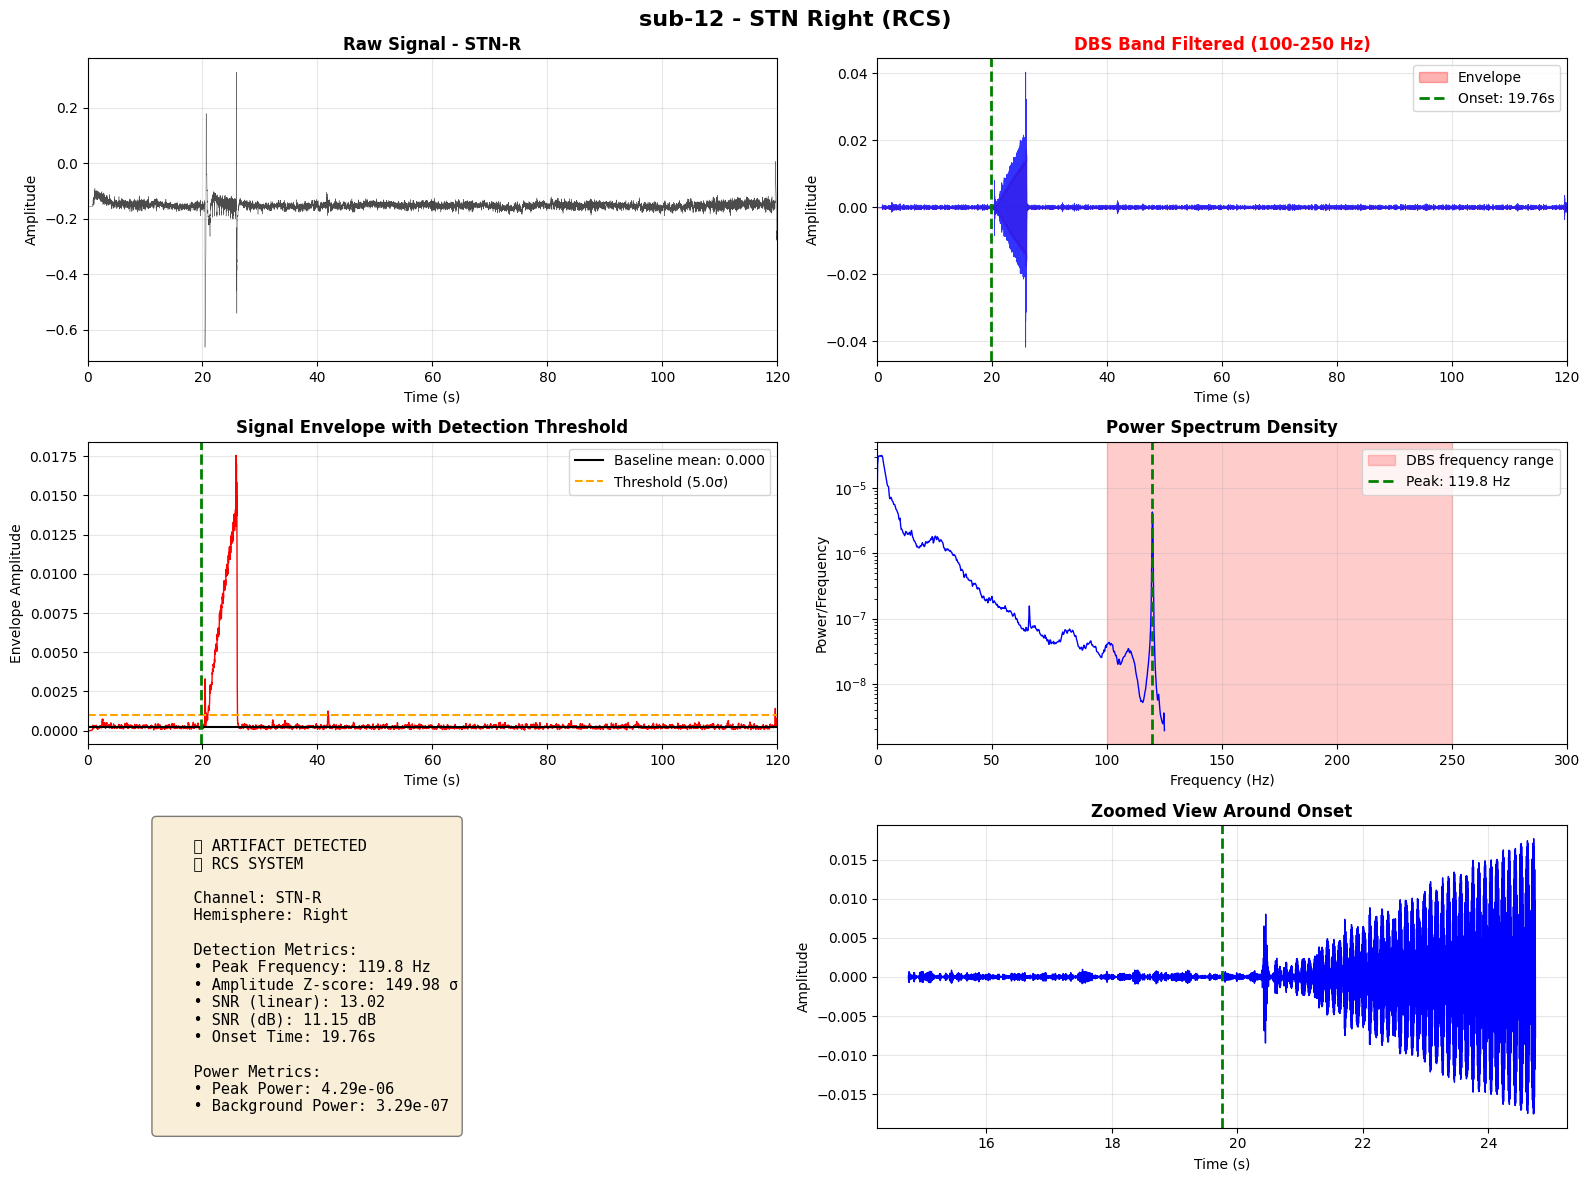


--------------------------------------------------
📊 Processing sub-14... (RCS)
--------------------------------------------------
  Left: ✅ Freq=100.8Hz, Z=146.6σ, SNR=0.14


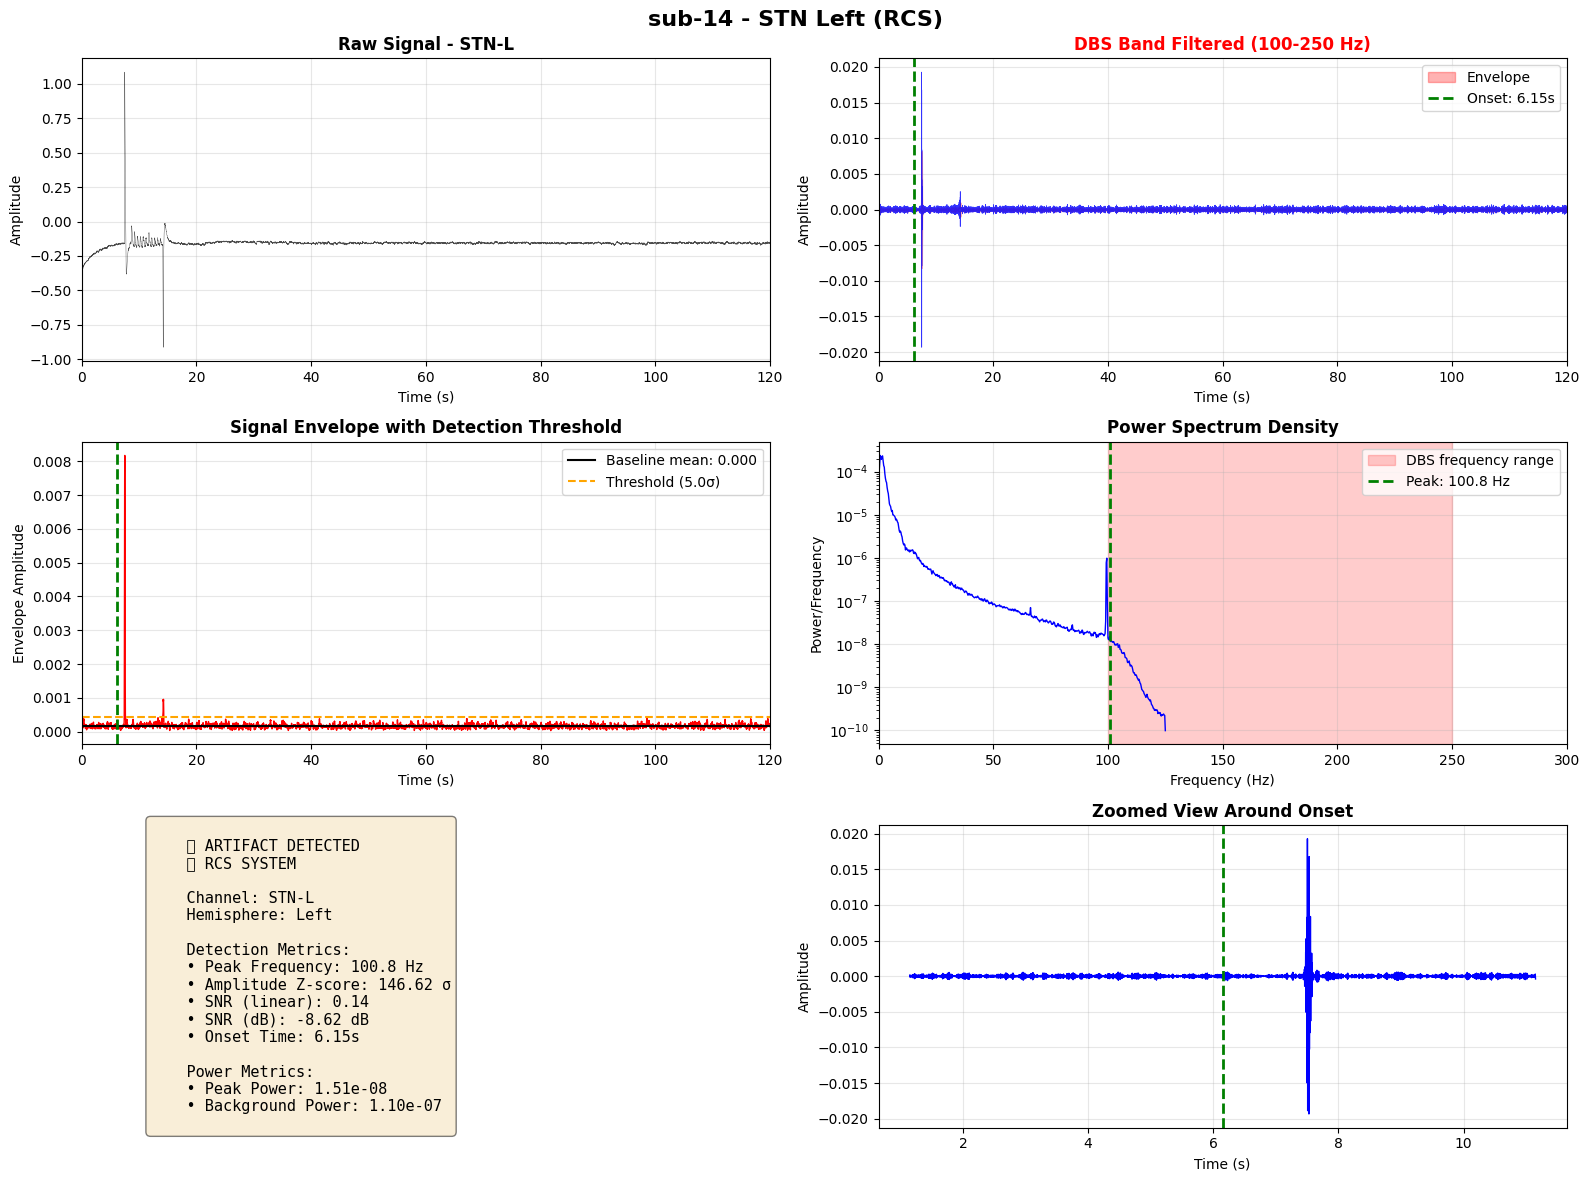

  Right: ✅ Freq=100.2Hz, Z=24.8σ, SNR=0.20


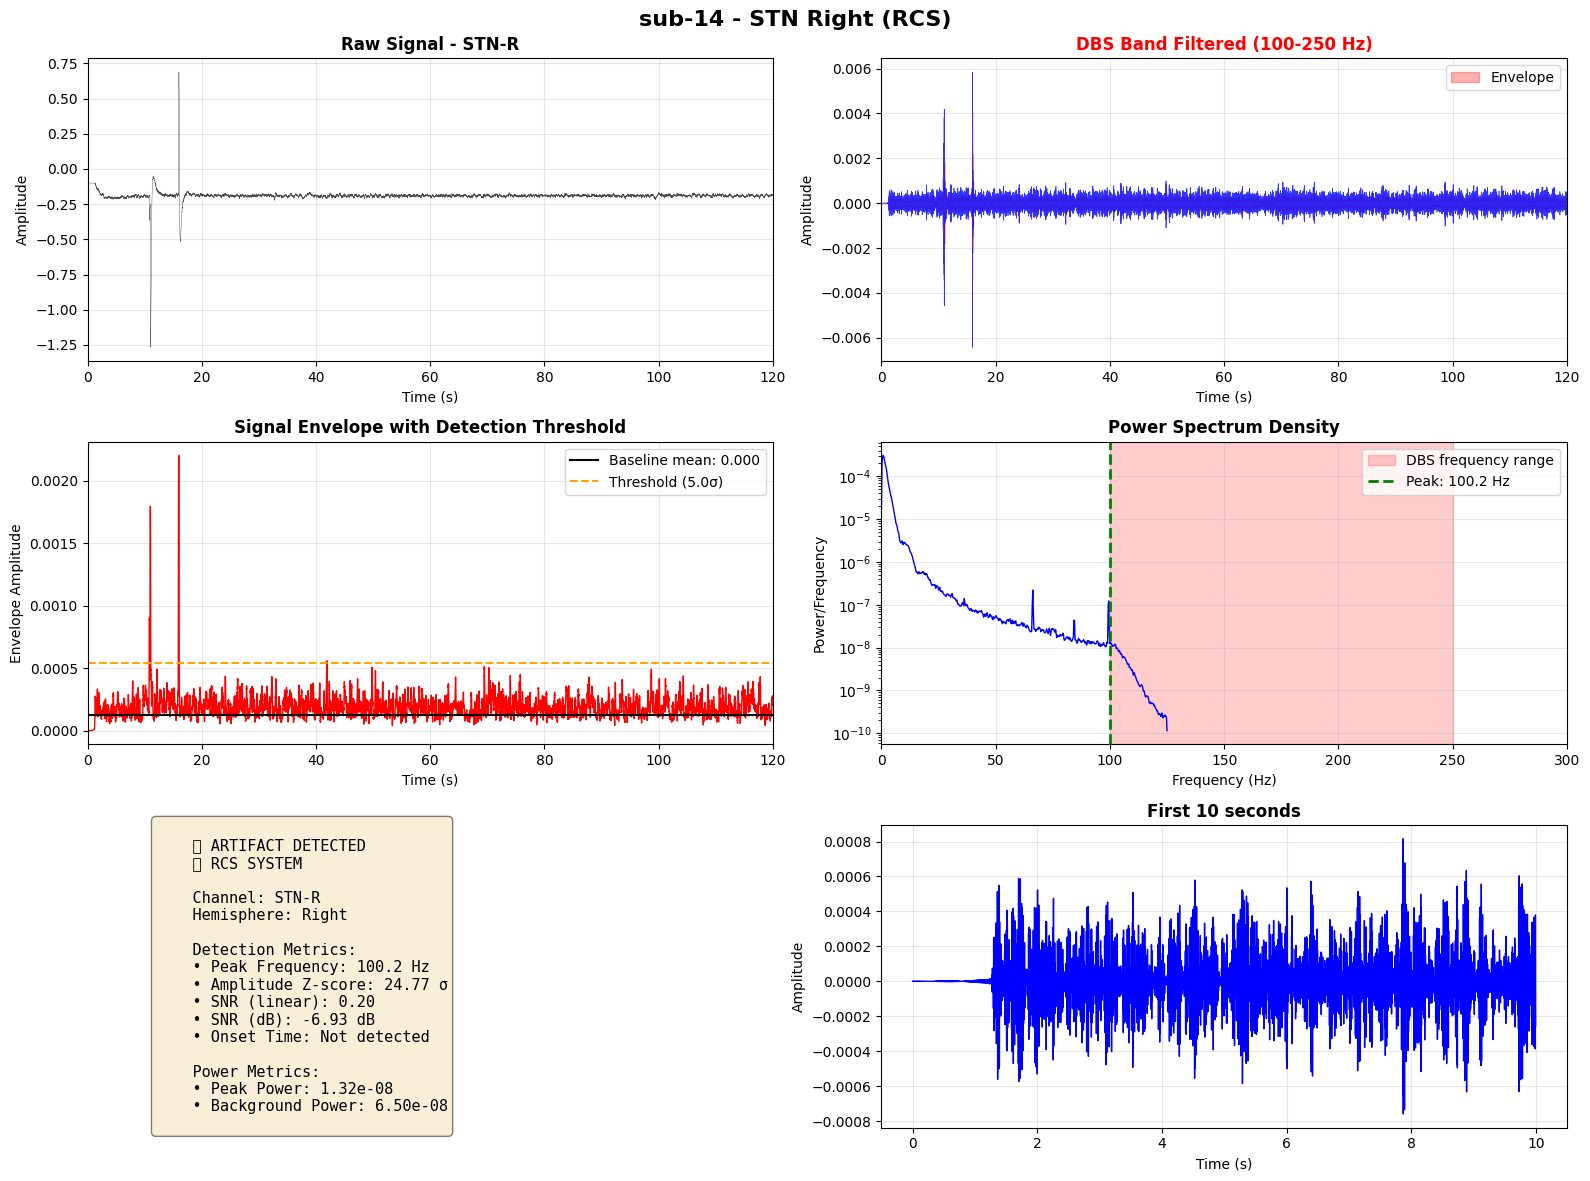


FINAL SUMMARY - TARGET SUBJECTS

 Subject  System Left Right      Left Metrics     Right Metrics DBS ON?                 Detection
 sub-01     RCS    ✅     ✅ 119.8Hz, 30.36SNR  119.8Hz, 1.35SNR   ✅ YES Left (119.8Hz, SNR=30.36)
 sub-05 PERCEPT    ❌     ✅  100.0Hz, 0.05SNR  123.8Hz, 1.11SNR   ✅ YES Right (123.8Hz, SNR=1.11)
 sub-07 PERCEPT    ✅     ❌  107.2Hz, 1.37SNR                     ✅ YES  Left (107.2Hz, SNR=1.37)
 sub-10 PERCEPT    ✅     ❌  107.2Hz, 3.28SNR  101.0Hz, 0.11SNR   ✅ YES  Left (107.2Hz, SNR=3.28)
 sub-12     RCS    ✅     ✅  119.8Hz, 0.30SNR 119.8Hz, 13.02SNR   ✅ YES  Left (119.8Hz, SNR=0.30)
 sub-14     RCS    ✅     ✅  100.8Hz, 0.14SNR  100.2Hz, 0.20SNR   ✅ YES  Left (100.8Hz, SNR=0.14)

CONCLUSION

🔴 RCS Subjects (n=3):
   sub-01: ✅ DBS ON (L:✅ R:✅)
   sub-12: ✅ DBS ON (L:✅ R:✅)
   sub-14: ✅ DBS ON (L:✅ R:✅)
   → 3/3 RCS subjects show DBS artifact

🔵 Percept Subjects (n=3):
   sub-05: ✅ DBS ON (L:❌ R:✅)
   sub-07: ✅ DBS ON (L:✅ R:❌)
   sub-10: ✅ DBS ON (L:✅ R:❌)
   →

In [5]:
# =============================================================================
# FINAL DBS ARTIFACT DETECTION - TARGET SUBJECTS WITH PLOTS
# =============================================================================

import mne
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import welch, find_peaks, butter, filtfilt
from scipy.ndimage import uniform_filter1d
import warnings
from typing import Optional, Dict, List, Tuple

warnings.filterwarnings('ignore')

# =============================================================================
# CONFIGURATION
# =============================================================================

IEEG_PATH = Path('/mnt/movement/users/jaizor/xtra/data/eeg/PD_iEEG')

# DBS frequency range
DBS_FREQ_RANGE = (100, 250)  # Hz

# System type definitions
RCS_SUBJECTS = ['sub-01', 'sub-12', 'sub-14']
PERCEPT_SUBJECTS = ['sub-05', 'sub-07', 'sub-10']

# FINAL TARGET SUBJECTS FOR ANALYSIS
TARGET_SUBJECTS = ['sub-01', 'sub-05', 'sub-07', 'sub-10', 'sub-12', 'sub-14']

# Detection thresholds
RCS_AMPLITUDE_THRESHOLD = 5.0  # RCS: Any amplitude > 5 is artifact
PERCEPT_SNR_THRESHOLD = 1.0    # Percept: SNR > 1 indicates artifact
PERCEPT_AMPLITUDE_THRESHOLD = 4.0  # Percept: Minimum amplitude

# =============================================================================
# Helper functions
# =============================================================================

def get_system_type(subject: str) -> str:
    """Get the recording system type for a subject"""
    if subject in RCS_SUBJECTS:
        return 'RCS'
    elif subject in PERCEPT_SUBJECTS:
        return 'PERCEPT'
    else:
        return 'UNKNOWN'

def format_onset_time(onset_time):
    """Format onset time, handling None values"""
    if onset_time is not None:
        return f"{onset_time:.2f}s"
    else:
        return "Not detected"

def detect_dbs_artifact(data: np.ndarray, fs: float, channel_name: str) -> Dict:
    """
    Detect DBS artifact in a signal.
    """
    # Apply bandpass filter for DBS range
    dbs_low, dbs_high = DBS_FREQ_RANGE
    nyquist = fs / 2
    dbs_high = min(dbs_high, nyquist - 1)
    
    b, a = butter(4, [dbs_low/nyquist, dbs_high/nyquist], btype='band')
    filtered = filtfilt(b, a, data)
    
    # Calculate envelope
    envelope = np.abs(filtered)
    smooth_env = uniform_filter1d(envelope, size=int(fs/10))
    
    # Baseline (first 5 seconds)
    baseline = smooth_env[:int(5*fs)]
    baseline_mean = np.mean(baseline)
    baseline_std = np.std(baseline)
    
    # Find onset
    onset_idx = None
    onset_time = None
    
    if len(smooth_env) > int(5*fs) and baseline_std > 0:
        derivative = np.diff(smooth_env, prepend=smooth_env[0])
        deriv_std = np.std(derivative[:int(5*fs)])
        
        for i in range(int(2*fs), len(smooth_env) - int(fs)):
            if deriv_std > 0 and derivative[i] > 2 * deriv_std:
                pre = np.mean(smooth_env[i-int(fs/5):i])
                post = np.mean(smooth_env[i:i+int(fs/5)])
                
                if post > pre * 1.2:
                    sustained = np.mean(smooth_env[i:i+int(fs*2)])
                    if sustained > baseline_mean + 3 * baseline_std:
                        onset_idx = i
                        onset_time = i / fs
                        break
    
    # Frequency analysis
    nperseg = min(int(fs * 4), len(data) // 4)
    freqs, psd = welch(data, fs, nperseg=nperseg)
    
    # Find peak in DBS range
    dbs_mask = (freqs >= dbs_low) & (freqs <= dbs_high)
    if np.any(dbs_mask):
        peak_idx = np.argmax(psd[dbs_mask])
        peak_freq = freqs[dbs_mask][peak_idx]
        peak_power = psd[dbs_mask][peak_idx]
        
        # Background power (avoiding peak region)
        bg_mask = (freqs >= 20) & (freqs <= 200) & (np.abs(freqs - peak_freq) > 10)
        if np.any(bg_mask):
            bg_power = np.mean(psd[bg_mask])
            snr_linear = peak_power / bg_power if bg_power > 0 else 0
            snr_db = 10 * np.log10(snr_linear) if snr_linear > 0 else 0
        else:
            bg_power = 0
            snr_linear = 0
            snr_db = 0
    else:
        peak_freq = 0
        snr_linear = 0
        snr_db = 0
        peak_power = 0
        bg_power = 0
    
    # Amplitude z-score
    amp_z = (np.max(smooth_env) - baseline_mean) / baseline_std if baseline_std > 0 else 0
    
    return {
        'channel': channel_name,
        'peak_freq': peak_freq,
        'amplitude_z': amp_z,
        'snr_linear': snr_linear,
        'snr_db': snr_db,
        'onset_time': onset_time,
        'filtered': filtered,
        'envelope': smooth_env,
        'raw_data': data,
        'freqs': freqs,
        'psd': psd,
        'fs': fs,
        'baseline_mean': baseline_mean,
        'baseline_std': baseline_std,
        'peak_power': peak_power,
        'bg_power': bg_power
    }

def load_ieeg_npz(filepath: Path) -> Tuple[np.ndarray, float, str]:
    """Load iEEG NPZ file"""
    data = np.load(filepath, allow_pickle=True)
    
    if 'data' in data:
        signal = data['data']
    else:
        signal = data['arr_0']
    
    if 'fs' in data:
        fs = float(data['fs'])
    elif 'sfreq' in data:
        fs = float(data['sfreq'])
    else:
        fs = 250.0
    
    channel_type = filepath.stem
    return signal, fs, channel_type

def get_stn_files(subject: str) -> List[Path]:
    """Get all STN files for a subject"""
    stn_files = []
    rest_path = IEEG_PATH / subject / 'DBSOFF' / 'rest'
    
    if rest_path.exists():
        for f in rest_path.glob('*.npz'):
            if 'STN' in f.name:
                stn_files.append(f)
    
    return stn_files

def determine_artifact_presence(result: Dict, system_type: str) -> bool:
    """Determine if artifact is present based on system type"""
    if system_type == 'RCS':
        # RCS: Any significant amplitude is artifact
        return result['amplitude_z'] > RCS_AMPLITUDE_THRESHOLD
    
    else:  # PERCEPT
        # Percept: Need both good SNR and reasonable amplitude
        return (result['snr_linear'] > PERCEPT_SNR_THRESHOLD and 
                result['amplitude_z'] > PERCEPT_AMPLITUDE_THRESHOLD)

# =============================================================================
# Plotting function
# =============================================================================

def plot_stn_artifact(result: Dict, subject: str, hemisphere: str, system_type: str):
    """Create comprehensive plot for STN channel."""
    fig, axes = plt.subplots(3, 2, figsize=(16, 12))
    
    fs = result['fs']
    data = result['raw_data']
    filtered = result['filtered']
    envelope = result['envelope']
    time = np.arange(len(data)) / fs
    
    # Limit to first 2 minutes for time series
    n_samples = min(int(120 * fs), len(data))
    
    # ===== Raw signal =====
    ax = axes[0, 0]
    ax.plot(time[:n_samples], data[:n_samples], 'k-', linewidth=0.3, alpha=0.7)
    ax.set_title(f'Raw Signal - {result["channel"]}', fontweight='bold')
    ax.set_ylabel('Amplitude')
    ax.set_xlabel('Time (s)')
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, min(120, len(data)/fs)])
    
    # ===== Filtered signal (DBS band) =====
    ax = axes[0, 1]
    ax.plot(time[:n_samples], filtered[:n_samples], 'b-', linewidth=0.5, alpha=0.8)
    ax.fill_between(time[:n_samples], -envelope[:n_samples], envelope[:n_samples], 
                    alpha=0.3, color='red', label='Envelope')
    
    if result['onset_time'] and result['onset_time'] < 120:
        ax.axvline(result['onset_time'], color='g', linestyle='--', linewidth=2,
                  label=f"Onset: {result['onset_time']:.2f}s")
    
    system_color = 'red' if system_type == 'RCS' else 'blue'
    ax.set_title(f'DBS Band Filtered ({DBS_FREQ_RANGE[0]}-{DBS_FREQ_RANGE[1]} Hz)', 
                 fontweight='bold', color=system_color)
    ax.set_ylabel('Amplitude')
    ax.set_xlabel('Time (s)')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, min(120, len(data)/fs)])
    
    # ===== Envelope and detection =====
    ax = axes[1, 0]
    ax.plot(time[:n_samples], envelope[:n_samples], 'r-', linewidth=1)
    
    if result['baseline_std'] > 0:
        threshold = RCS_AMPLITUDE_THRESHOLD if system_type == 'RCS' else PERCEPT_AMPLITUDE_THRESHOLD
        ax.axhline(result['baseline_mean'], color='k', linestyle='-', 
                   label=f"Baseline mean: {result['baseline_mean']:.3f}")
        ax.axhline(result['baseline_mean'] + threshold * result['baseline_std'], 
                   color='orange', linestyle='--', label=f"Threshold ({threshold}σ)")
    
    if result['onset_time'] and result['onset_time'] < 120:
        ax.axvline(result['onset_time'], color='g', linestyle='--', linewidth=2)
    
    ax.set_title('Signal Envelope with Detection Threshold', fontweight='bold')
    ax.set_ylabel('Envelope Amplitude')
    ax.set_xlabel('Time (s)')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, min(120, len(data)/fs)])
    
    # ===== Power Spectrum =====
    ax = axes[1, 1]
    freqs = result['freqs']
    psd = result['psd']
    
    ax.semilogy(freqs, psd, 'b-', linewidth=1)
    ax.axvspan(DBS_FREQ_RANGE[0], DBS_FREQ_RANGE[1], alpha=0.2, color='red', 
               label='DBS frequency range')
    
    if result['peak_freq'] > 0:
        ax.axvline(result['peak_freq'], color='g', linestyle='--', linewidth=2,
                  label=f"Peak: {result['peak_freq']:.1f} Hz")
    
    ax.set_title(f'Power Spectrum Density', fontweight='bold')
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Power/Frequency')
    ax.set_xlim([0, 300])
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    
    # ===== Metrics summary =====
    ax = axes[2, 0]
    ax.axis('off')
    
    has_artifact = determine_artifact_presence(result, system_type)
    status = "✅ ARTIFACT DETECTED" if has_artifact else "❌ NO ARTIFACT"
    system_emoji = "🔴" if system_type == 'RCS' else "🔵"
    
    metrics_text = f"""
    {status}
    {system_emoji} {system_type} SYSTEM
    
    Channel: {result['channel']}
    Hemisphere: {hemisphere}
    
    Detection Metrics:
    • Peak Frequency: {result['peak_freq']:.1f} Hz
    • Amplitude Z-score: {result['amplitude_z']:.2f} σ
    • SNR (linear): {result['snr_linear']:.2f}
    • SNR (dB): {result['snr_db']:.2f} dB
    • Onset Time: {format_onset_time(result['onset_time'])}
    
    Power Metrics:
    • Peak Power: {result['peak_power']:.2e}
    • Background Power: {result['bg_power']:.2e}
    """
    
    ax.text(0.1, 0.5, metrics_text, transform=ax.transAxes, fontsize=11,
            verticalalignment='center', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # ===== Zoomed view =====
    ax = axes[2, 1]
    if result['onset_time'] and result['onset_time'] < 120:
        onset_sample = int(result['onset_time'] * fs)
        window = int(10 * fs)
        start = max(0, onset_sample - window//2)
        end = min(len(data), onset_sample + window//2)
        zoom_time = time[start:end]
        zoom_filtered = filtered[start:end]
        ax.plot(zoom_time, zoom_filtered, 'b-', linewidth=1)
        ax.axvline(result['onset_time'], color='g', linestyle='--', linewidth=2)
        ax.set_title('Zoomed View Around Onset', fontweight='bold')
    else:
        window = int(10 * fs)
        zoom_filtered = filtered[:window]
        zoom_time = time[:window]
        ax.plot(zoom_time, zoom_filtered, 'b-', linewidth=1)
        ax.set_title('First 10 seconds', fontweight='bold')
    
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Amplitude')
    ax.grid(True, alpha=0.3)
    
    plt.suptitle(f'{subject} - STN {hemisphere} ({system_type})', 
                 fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    return fig

# =============================================================================
# Main processing function
# =============================================================================

def analyze_target_subjects():
    """Analyze only the 6 target subjects and show all plots"""
    
    print("="*70)
    print("FINAL DBS ARTIFACT DETECTION - TARGET SUBJECTS WITH PLOTS")
    print("="*70)
    print(f"\nAnalyzing {len(TARGET_SUBJECTS)} target subjects:")
    for s in TARGET_SUBJECTS:
        system = get_system_type(s)
        emoji = "🔴" if system == 'RCS' else "🔵"
        print(f"  {emoji} {s} ({system})")
    
    results = []
    
    for subject in TARGET_SUBJECTS:
        system_type = get_system_type(subject)
        
        print(f"\n{'-'*50}")
        print(f"📊 Processing {subject}... ({system_type})")
        print(f"{'-'*50}")
        
        subject_result = {
            'subject': subject,
            'system_type': system_type,
            'left': None,
            'right': None,
            'left_result': None,
            'right_result': None,
            'artifact_detected': False,
            'detection_hemisphere': None,
            'detection_freq': None,
            'detection_snr': None,
            'detection_z': None
        }
        
        stn_files = get_stn_files(subject)
        
        if not stn_files:
            print(f"  ❌ No STN files found")
            results.append(subject_result)
            continue
        
        for stn_file in sorted(stn_files):
            signal, fs, channel_name = load_ieeg_npz(stn_file)
            
            if signal.ndim == 1:
                signal = signal.reshape(1, -1)
            
            for ch_idx in range(signal.shape[0]):
                if signal.shape[0] > 1:
                    ch_display = f"{channel_name}_ch{ch_idx+1}"
                else:
                    ch_display = channel_name
                
                # Detect artifact
                result = detect_dbs_artifact(signal[ch_idx, :], fs, ch_display)
                has_artifact = determine_artifact_presence(result, system_type)
                
                # Determine hemisphere
                if 'L' in channel_name or 'LEFT' in channel_name.upper():
                    subject_result['left'] = {
                        'detected': has_artifact,
                        'freq': result['peak_freq'],
                        'snr': result['snr_linear'],
                        'z': result['amplitude_z']
                    }
                    subject_result['left_result'] = result
                    hemisphere = 'Left'
                elif 'R' in channel_name or 'RIGHT' in channel_name.upper():
                    subject_result['right'] = {
                        'detected': has_artifact,
                        'freq': result['peak_freq'],
                        'snr': result['snr_linear'],
                        'z': result['amplitude_z']
                    }
                    subject_result['right_result'] = result
                    hemisphere = 'Right'
                else:
                    hemisphere = 'Unknown'
                
                # Print detection status
                status = "✅" if has_artifact else "❌"
                print(f"  {hemisphere}: {status} Freq={result['peak_freq']:.1f}Hz, "
                      f"Z={result['amplitude_z']:.1f}σ, SNR={result['snr_linear']:.2f}")
                
                # SHOW THE PLOT for every channel
                plot_stn_artifact(result, subject, hemisphere, system_type)
        
        # Determine if subject has DBS artifact (either hemisphere)
        left_detected = subject_result['left'] and subject_result['left']['detected']
        right_detected = subject_result['right'] and subject_result['right']['detected']
        
        subject_result['artifact_detected'] = left_detected or right_detected
        
        if left_detected:
            subject_result['detection_hemisphere'] = 'Left'
            subject_result['detection_freq'] = subject_result['left']['freq']
            subject_result['detection_snr'] = subject_result['left']['snr']
            subject_result['detection_z'] = subject_result['left']['z']
        elif right_detected:
            subject_result['detection_hemisphere'] = 'Right'
            subject_result['detection_freq'] = subject_result['right']['freq']
            subject_result['detection_snr'] = subject_result['right']['snr']
            subject_result['detection_z'] = subject_result['right']['z']
        
        results.append(subject_result)
    
    return results

# =============================================================================
# Summary and visualization
# =============================================================================

def create_summary_table(results: List[Dict]):
    """Create a clean summary table"""
    
    print("\n" + "="*70)
    print("FINAL SUMMARY - TARGET SUBJECTS")
    print("="*70)
    
    summary_data = []
    for r in results:
        # Determine which hemisphere(s) have detection
        left_status = "✅" if r['left'] and r['left']['detected'] else "❌"
        right_status = "✅" if r['right'] and r['right']['detected'] else "❌"
        
        # Format left metrics
        left_metrics = ""
        if r['left']:
            left_metrics = f"{r['left']['freq']:.1f}Hz, {r['left']['snr']:.2f}SNR"
        
        # Format right metrics
        right_metrics = ""
        if r['right']:
            right_metrics = f"{r['right']['freq']:.1f}Hz, {r['right']['snr']:.2f}SNR"
        
        # Format detection info
        if r['artifact_detected']:
            detection_info = f"{r['detection_hemisphere']} "
            detection_info += f"({r['detection_freq']:.1f}Hz, "
            detection_info += f"SNR={r['detection_snr']:.2f})"
        else:
            detection_info = "NO DETECTION"
        
        summary_data.append({
            'Subject': r['subject'],
            'System': r['system_type'],
            'Left': left_status,
            'Right': right_status,
            'Left Metrics': left_metrics,
            'Right Metrics': right_metrics,
            'DBS ON?': '✅ YES' if r['artifact_detected'] else '❌ NO',
            'Detection': detection_info
        })
    
    df = pd.DataFrame(summary_data)
    print("\n", df.to_string(index=False))
    
    return df

def print_conclusion(results: List[Dict]):
    """Print final conclusion"""
    
    print("\n" + "="*70)
    print("CONCLUSION")
    print("="*70)
    
    # Count detections by system type
    rcs_detected = sum(1 for r in results if r['system_type'] == 'RCS' and r['artifact_detected'])
    percept_detected = sum(1 for r in results if r['system_type'] == 'PERCEPT' and r['artifact_detected'])
    
    print(f"\n🔴 RCS Subjects (n={len(RCS_SUBJECTS)}):")
    for r in results:
        if r['system_type'] == 'RCS':
            print(f"   {r['subject']}: {'✅ DBS ON' if r['artifact_detected'] else '❌ DBS OFF'} "
                  f"(L:{'✅' if r['left'] and r['left']['detected'] else '❌'} "
                  f"R:{'✅' if r['right'] and r['right']['detected'] else '❌'})")
    print(f"   → {rcs_detected}/{len(RCS_SUBJECTS)} RCS subjects show DBS artifact")
    
    print(f"\n🔵 Percept Subjects (n={len(PERCEPT_SUBJECTS)}):")
    for r in results:
        if r['system_type'] == 'PERCEPT':
            print(f"   {r['subject']}: {'✅ DBS ON' if r['artifact_detected'] else '❌ DBS OFF'} "
                  f"(L:{'✅' if r['left'] and r['left']['detected'] else '❌'} "
                  f"R:{'✅' if r['right'] and r['right']['detected'] else '❌'})")
    print(f"   → {percept_detected}/{len(PERCEPT_SUBJECTS)} Percept subjects show DBS artifact")
    
    print(f"\n{'='*70}")
    print(f"🎯 FINAL: {sum(1 for r in results if r['artifact_detected'])}/{len(results)} "
          f"target subjects have DBS artifact detected")
    print("="*70)

# =============================================================================
# Main execution
# =============================================================================

def main():
    # Run analysis on target subjects (this will show all plots)
    results = analyze_target_subjects()
    
    # Create summary table
    summary_df = create_summary_table(results)
    
    # Print conclusion
    print_conclusion(results)
    
    # Save summary to CSV
    summary_df.to_csv('dbs_artifact_detection_target_subjects.csv', index=False)
    print("\n📁 Summary saved to: dbs_artifact_detection_target_subjects.csv")

if __name__ == '__main__':
    main()